# Simulation Implementation - Task 1 (Deep Design, Review-Aligned)

## Goal of Task 1
Design a **minimal but expressive hidden-state representation** for a research-grade customer support simulator.  
This state must support valid RL training for escalation policy optimization under economic objectives.

---

## Plan for Task 1

1. Define a structured latent state with **static** and **dynamic** factors.  
2. Ensure each variable is economically and behaviorally meaningful.  
3. Tie variable choices to available datasets (Twitter + OpenAssistant).  
4. Specify initialization distributions with bounded ranges and interpretable priors.  
5. Apply post-review refinements only where they improve correctness and RL stability.

---

## 1) Hidden State Definition

Let the episode latent state at turn $t$ be:

$$
z_t = \{s, x_t\}
$$

where:

- $s$: static variables sampled at conversation start
- $x_t$: dynamic variables that evolve after each agent action

### 1.1 Static Variables (Sample Once at Reset)

$$
s = \{\text{customer\_tier}, \text{customer\_value\_weight}, \text{problem\_type}, d, \psi\}
$$

- **customer_tier** $\in \{\text{Free, Pro, Business, Enterprise}\}$
- **customer_value_weight** $\in [0,1]$ (normalized economic value at risk)
- **problem_type** $\in \mathcal{P}$, e.g., billing, login, bug, refund, integration, performance, account_access, other
- **difficulty** $d \in [0,1]$: intrinsic complexity of issue
- **persona parameters** $\psi$: compact controls for behavior dynamics

Recommended persona parameterization:

$$
\psi = \{\rho, \sigma, \tau\}
$$

- $\rho \in [0,1]$: patience
- $\sigma \in [0,1]$: sensitivity to failures and poor outcomes
- $\tau \in [0,1]$: tolerance to repeated failed attempts

### 1.2 Dynamic Variables (Update Every Turn)

$$
x_t = \{f_t, i_t, n_t, r_t, k_t\}
$$

- **frustration** $f_t \in [0,1]$
- **information_collected** $i_t \in [0,1]$
- **turn_count** $n_t \in \{0,1,\dots,T_{\max}\}$
- **resolved flag** $r_t \in \{0,1\}$
- **consecutive_failed_solutions** $k_t \in \{0,1,2,\dots\}$

### 1.3 Derived Variable (Not Independently Transitioned)

- **resolution_probability** $p_t$ is derived, not directly transitioned.

$$
p_t = g(i_t, d, f_t, \psi, \text{problem\_type}, \text{optional context features})
$$

Consistency rule: $p_t$ must be recomputed each step from current state; no separate stochastic update is allowed.

---

## 2) Why These Variables (Dataset Justification)

### 2.1 Twitter Dataset Justification
Twitter support threads provide:

- **Unresolved / no-reply patterns**  
  -> informs failure proxy and frustration accumulation.
- **Escalation-like language and complaint intensity**  
  -> informs sensitivity/tolerance behavior and escalation pressure.
- **Turn depth + sentiment progression**  
  -> informs realistic trajectory of $f_t$ and episode horizon $n_t$.

So Twitter primarily supports estimation of:

- frustration growth behaviors
- unresolved likelihood under repeated failed handling
- escalation-prone interaction signatures

### 2.2 OpenAssistant (OASST1) Justification
OpenAssistant provides:

- quality scores / rankings in $[0,1]$ or normalized scales
- quality-linked response preference signals

This supports calibration of:

- relationship between answer quality and success odds
- derived success model used to compute $p_t$

So OASST1 primarily supports:

- the success model component
- quality-conditioned satisfaction proxy

---

## 3) Initialization Distributions (Reset)

Use a factorized generative initialization:

$$
P(s, x_0) = P(\text{tier}) P(\text{problem\_type} \mid \text{tier}) P(d \mid \text{problem\_type}, \text{tier}) P(\psi \mid \text{tier}) P(x_0 \mid s)
$$

### 3.1 Static Variable Priors

1. **Tier prior**

$$
\text{customer\_tier} \sim \text{Categorical}(\pi_{\text{tier}})
$$

2. **Economic value weight (deterministic from tier by default)**

$$
\text{customer\_value\_weight} = m(\text{tier})
$$

Example monotone mapping:

- Free -> 0.00
- Pro -> 0.35
- Business -> 0.65
- Enterprise -> 1.00

3. **Problem type prior (tier-conditional)**

$$
\text{problem\_type} \sim \text{Categorical}(\pi_{\text{problem} \mid \text{tier}})
$$

4. **Difficulty prior**

$$
d \sim \text{Beta}(\alpha_{p,t}, \beta_{p,t})
$$

5. **Persona prior**

Option A (cluster-based Gaussian then clipped):

$$
(\rho,\sigma,\tau) \mid c \sim \mathcal{N}(\mu_c, \Sigma_c), \quad \text{clip to } [0,1]^3
$$

Option B (simpler independent Beta priors):

$$
\rho \sim \text{Beta}(a_\rho^c,b_\rho^c), \; \sigma \sim \text{Beta}(a_\sigma^c,b_\sigma^c), \; \tau \sim \text{Beta}(a_\tau^c,b_\tau^c)
$$

### 3.2 Dynamic Variables at Reset

Set deterministic defaults:

- $n_0 = 0$
- $r_0 = 0$
- $k_0 = 0$

Sample bounded initial conditions:

$$
i_0 \sim \text{Beta}(1.2, 6.0)
$$

$$
f_0 \sim \text{Beta}(1.5, 8.0)
$$

Initialize derived resolution probability:

$$
p_0 = \text{clip}\left(\sigma\left(\theta_0 + \theta_i i_0 - \theta_d d - \theta_f f_0\right), 0, 1\right)
$$

where $\sigma(\cdot)$ is sigmoid and coefficients satisfy:

- $\theta_i > 0$ (more info helps)
- $\theta_d > 0$ (higher difficulty hurts)
- $\theta_f > 0$ (higher frustration lowers solve odds)

---

## 4) Structured Frustration Dynamics Framework (to finalize in Task 2)

Frustration updates should follow a bounded decomposition:

$$
\Delta f_t = a_0(1-\rho) + a_1\sigma\,\mathbf{1}_{\text{failed\_attempt}} + a_2\,\phi(k_t,\tau) - a_3\,\mathbf{1}_{\text{effective\_repair}} - a_4\,\mathbf{1}_{\text{clear\_progress}}
$$

$$
f_{t+1} = \text{clip}(f_t + \Delta f_t, 0, 1)
$$

with optional amplification term:

$$
\phi(k_t,\tau) = \frac{k_t}{k_t + c}(1-\tau)
$$

This ensures persona-conditioned, interpretable, and stable frustration trajectories.

---

## 5) Variable Ranges and Integrity Constraints

### 5.1 Domains

- Continuous bounded: $d, f_t, i_t, p_t, \rho, \sigma, \tau, \text{customer\_value\_weight} \in [0,1]$
- Discrete categorical: tier, problem_type, persona_cluster
- Binary: $r_t \in \{0,1\}$
- Integer turn index: $n_t \in \{0,\dots,T_{\max}\}$
- Integer counter: $k_t \in \{0,1,2,\dots\}$

### 5.2 Hard Constraints

- If $r_t = 1$, episode is terminal.
- All continuous state updates must be clipped to $[0,1]$.
- $p_t$ is always derived from current state (never independently updated).
- State transitions cannot depend on generated text directly (text is optional realism layer only).

---

## 6) Calibration Checklist (Data-to-Model)

1. Fit $\pi_{\text{tier}}$ and $\pi_{\text{problem} \mid \text{tier}}$ from unified schema outputs.
2. Fit difficulty Beta priors $(\alpha_{p,t}, \beta_{p,t})$ via issue-level complexity proxies.
3. Fit persona clusters (GMM planned in pipeline), then map to $(\rho,\sigma,\tau)$ distributions.
4. Estimate $\theta$ parameters in the $p_t$ derivation using OpenAssistant quality-success relationship.
5. Use Twitter unresolved/escalation proxies to validate initial $f_0$ and frustration-risk alignment.
6. Calibrate tier-to-value mapping $m(\text{tier})$ using normalized CLV if available.

---

## 7) Outputs of Task 1 (for downstream tasks)

This task yields:

- final hidden state schema
- variable ranges and constraints
- initialization distributions
- persona parameterization
- explicit treatment of $p_t$ as derived
- calibration protocol tied to available datasets

These become fixed inputs for Task 2 (transition equations), Task 3 (economic reward), and full SupportEnv implementation.

---

## Notes

- This simulator is **not** a chatbot model.
- The latent state and equations are the core environment dynamics.
- RAG/LLM components, if used, are auxiliary realism layers only and cannot replace transition logic.
- Extended 7-action taxonomy can be plugged in without changing hidden-state fundamentals.

## Task 1 Calibration (Notebook Workflow)

This section implements the Task 1 calibration step-by-step so each estimate is inspectable.

What this notebook section does:

1. Loads real Twitter and OpenAssistant datasets.
2. Separates assumed business priors from data-driven estimates.
3. Estimates problem-type priors and confidence diagnostics.
4. Calibrates difficulty/frustration/persona proxies from Twitter threads.
5. Fits success-model coefficients from OpenAssistant data.
6. Writes a calibration artifact JSON for runtime use.

Why this notebook flow is useful:

- easy debugging of each intermediate table
- direct visual inspection of distributions
- transparent traceability from data to calibrated parameter

In [12]:
from pathlib import Path
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make plots readable in notebook
plt.rcParams['figure.figsize'] = (10, 4)

# Resolve repository root and CustomerSupportBandit path robustly.
def find_repo_root(start: Path) -> Path:
    cur = start.resolve()
    for candidate in [cur] + list(cur.parents):
        if (candidate / "CustomerSupportBandit").exists() and (candidate / "Simulation_2").exists():
            return candidate
    raise RuntimeError("Could not locate repository root from current working directory")

REPO_ROOT = find_repo_root(Path.cwd())
CSB_ROOT = REPO_ROOT / "CustomerSupportBandit"

if str(CSB_ROOT) not in sys.path:
    sys.path.insert(0, str(CSB_ROOT))

from config import DATA_PATHS, OUTPUT_DIR
from data.twitter_loader import load_twitter_data, reconstruct_threads, add_escalation_labels
from data.openassistant_loader import load_openassistant_data, build_conversation_trees
from data.calibrate_task1 import (
    calibrate_task1,
    _build_twitter_state_table,
    _estimate_personas,
    _fit_success_model_from_oasst,
    _method_of_moments_beta,
)

print("Repo root:", REPO_ROOT)
print("CustomerSupportBandit root:", CSB_ROOT)

Repo root: /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service
CustomerSupportBandit root: /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/CustomerSupportBandit


### Assumed vs Data-Driven

Assumed by design (your business choices):

- tier_prior
- tier_value_weight

Learned from data in this notebook:

- problem_type_prior
- problem_type_inference_stats
- difficulty_beta_by_problem_type
- persona_profiles and persona_weights
- success_model coefficients (theta0, theta_i, theta_d, theta_f)

This separation helps keep policy assumptions explicit while still learning behavior dynamics empirically.

In [13]:
# Check dataset availability before calibration.
required_paths = {
    "twitter": Path(DATA_PATHS["twitter"]),
    "openassistant_train_csv": Path(DATA_PATHS["openassistant_train_csv"]),
    "openassistant_val_csv": Path(DATA_PATHS["openassistant_val_csv"]),
}

for name, p in required_paths.items():
    print(f"{name}:", p, "| exists:", p.exists())

missing = [name for name, p in required_paths.items() if not p.exists()]
if missing:
    raise FileNotFoundError(f"Missing required dataset files: {missing}")

twitter: /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/datasets/twitter/twcs.csv | exists: True
openassistant_train_csv: /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/datasets/openassistant/oasst1-train.csv | exists: True
openassistant_val_csv: /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/datasets/openassistant/oasst1-val.csv | exists: True


In [14]:
# Step 1: Load and reconstruct Twitter conversation threads.
TWITTER_SAMPLE_FRAC = 0.5
TWITTER_MAX_THREADS = 120000
SEED = 42

tw_raw = load_twitter_data(sample_frac=TWITTER_SAMPLE_FRAC, random_state=SEED)
threads = reconstruct_threads(tw_raw)

if TWITTER_MAX_THREADS is not None and len(threads) > TWITTER_MAX_THREADS:
    threads = threads.sample(n=TWITTER_MAX_THREADS, random_state=SEED).reset_index(drop=True)

threads = add_escalation_labels(threads)
print("Twitter rows loaded:", len(tw_raw))
print("Twitter threads used:", len(threads))
threads.head(3)

Loading Twitter CS data from /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/datasets/twitter/twcs.csv ...
  Sampled 1,405,887 rows (50%)


Loading Twitter CS data from /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/datasets/twitter/twcs.csv ...
  Sampled 1,405,887 rows (50%)


/Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/CustomerSupportBandit/data/twitter_loader.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')


Loading Twitter CS data from /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/datasets/twitter/twcs.csv ...
  Sampled 1,405,887 rows (50%)


/Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/CustomerSupportBandit/data/twitter_loader.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')


  Loaded 1,405,887 tweets | Inbound: 769,810 | Outbound: 636,077
Reconstructing conversation threads ...
  Reconstructed 394,746 threads (avg 1.7 turns)
Adding escalation proxy labels ...
  Escalation rate: 56.2%
    - Phrase-based: 3.1%
    - No reply: 50.0%
    - Long thread (>3 turns): 4.9%
Twitter rows loaded: 1405887
Twitter threads used: 120000


Loading Twitter CS data from /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/datasets/twitter/twcs.csv ...
  Sampled 1,405,887 rows (50%)


/Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/CustomerSupportBandit/data/twitter_loader.py:45: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['created_at'] = pd.to_datetime(df['created_at'], errors='coerce')


  Loaded 1,405,887 tweets | Inbound: 769,810 | Outbound: 636,077
Reconstructing conversation threads ...
  Reconstructed 394,746 threads (avg 1.7 turns)
Adding escalation proxy labels ...
  Escalation rate: 56.2%
    - Phrase-based: 3.1%
    - No reply: 50.0%
    - Long thread (>3 turns): 4.9%
Twitter rows loaded: 1405887
Twitter threads used: 120000


,thread_id,tweets,num_turns,brand,has_brand_reply,customer_texts,brand_texts,num_customer_msgs,num_brand_msgs,has_escalation_phrase,escalation_phrases_found,escalation_needed
0,733634,[Hi @O2 I just got the below text message but ...,3,O2,True,Hi @O2 I just got the below text message but c...,@295565 🤔 It looks like you have plenty left B...,2,1,False,[],0
1,2017897,"[@sizehelpteam hi, how do I go about in return...",2,sizehelpteam,True,"@sizehelpteam hi, how do I go about in returni...","@596741 Hello,\n\nIf you are a UK customer you...",1,1,False,[],0
2,1013192,"[Tried Premium yet? Your favorite music, ad-fr...",1,None,False,"Tried Premium yet? Your favorite music, ad-fre...",,1,0,False,[],1


## Dataset Overview: Company Distribution

Why restrict to tech companies?

- The target deployment is a Slack-like support environment, which is tech-heavy in language and workflows.
- Restricting to tech firms improves domain consistency, so estimated transition and behavior parameters are more relevant.
- This reduces cross-domain noise (e.g., airlines, retail, telecom-only conventions) during calibration.

This overview first visualizes the full company distribution and then the selected tech-company distribution. After this point, all Twitter-based calibration steps use only the tech-company subset.

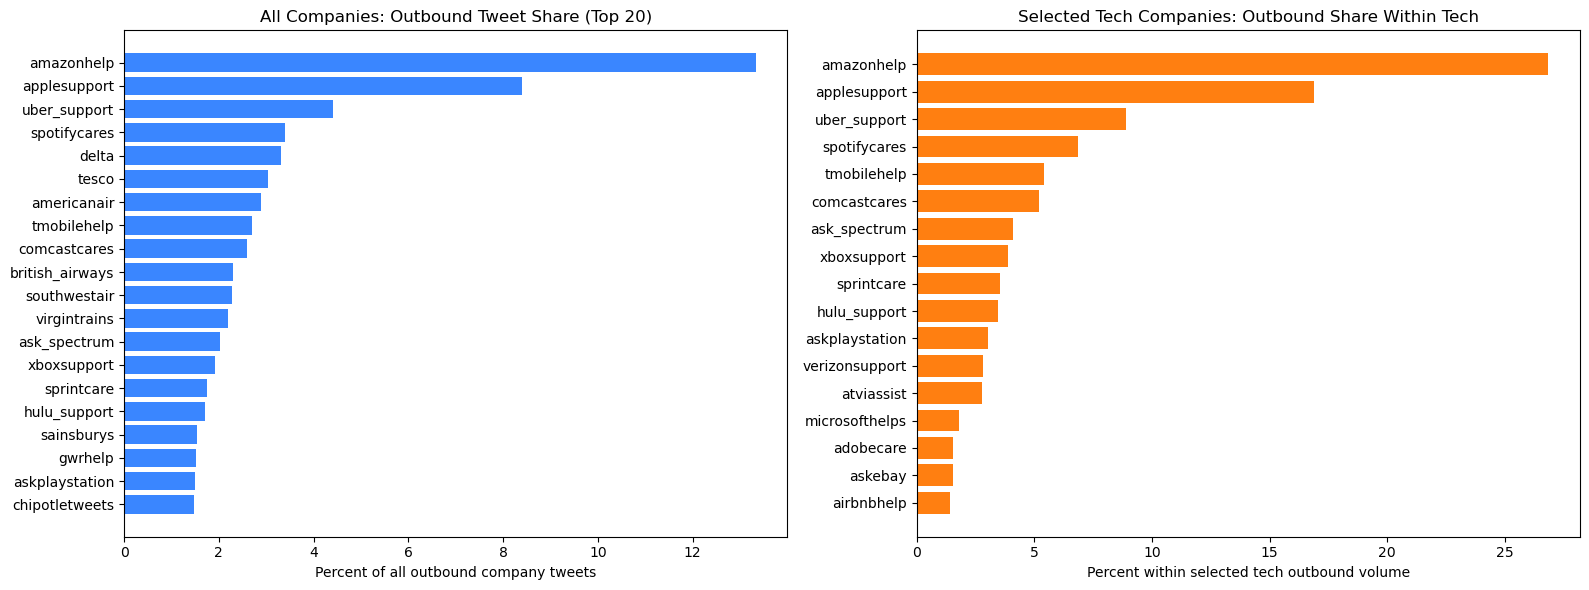

Rows scanned in TWCS: 2,811,774
Unique outbound companies (all): 108
Selected tech handles present in data: 17
['adobecare', 'airbnbhelp', 'amazonhelp', 'applesupport', 'ask_spectrum', 'askebay', 'askplaystation', 'atviassist', 'comcastcares', 'hulu_support', 'microsofthelps', 'spotifycares', 'sprintcare', 'tmobilehelp', 'uber_support', 'verizonsupport', 'xboxsupport']


In [15]:
import re
from collections import Counter

TECH_COMPANIES = {
    "applesupport", "amazonhelp", "uber_support", "spotifycares", "tmobilehelp",
    "comcastcares", "ask_spectrum", "xboxsupport", "hulu_support", "askplaystation",
    "sprintcare", "verizonsupport", "microsofthelps", "googlenesthelp", "youtube",
    "airbnbhelp", "dropbox", "slackhq", "discord", "adobecare", "atviassist",
    "microsoft", "google", "netflixhelps", "eahelp", "askebay", "paypal", "intuit"
}

TWITTER_PATH = DATA_PATHS["twitter"]
CHUNKSIZE = 200_000
MENTION_RE = re.compile(r"@([A-Za-z0-9_]{1,15})")


def _to_bool(x):
    if isinstance(x, bool):
        return x
    if pd.isna(x):
        return False
    return str(x).strip().lower() in {"true", "1", "t", "yes"}


def _counter_to_df(counter, label):
    total = sum(counter.values())
    df = (
        pd.Series(counter, dtype="int64")
        .rename_axis("company")
        .reset_index(name="count")
        .sort_values("count", ascending=False)
        .reset_index(drop=True)
    )
    df["pct"] = (100.0 * df["count"] / total) if total else 0.0
    df["distribution"] = label
    return df


outbound_tweet_counts = Counter()
inbound_thread_counts = Counter()
rows_scanned = 0

for chunk in pd.read_csv(
    TWITTER_PATH,
    usecols=["author_id", "inbound", "text", "in_response_to_tweet_id"],
    chunksize=CHUNKSIZE,
):
    rows_scanned += len(chunk)
    inbound_mask = chunk["inbound"].map(_to_bool)

    out_auth = chunk.loc[~inbound_mask, "author_id"].dropna().astype(str).str.lower()
    outbound_tweet_counts.update(out_auth.tolist())

    thread_starts = chunk.loc[inbound_mask & chunk["in_response_to_tweet_id"].isna(), "text"].dropna().astype(str)
    called = thread_starts.str.extract(MENTION_RE, expand=False).dropna().str.lower()
    inbound_thread_counts.update(called.tolist())


df_outbound = _counter_to_df(outbound_tweet_counts, "outbound_tweet_share")
df_threads = _counter_to_df(inbound_thread_counts, "inbound_thread_start_share")
tech_present = sorted(set(df_outbound["company"]).intersection(TECH_COMPANIES))

tech_outbound = df_outbound[df_outbound["company"].isin(tech_present)].copy()
tech_outbound_total = tech_outbound["count"].sum()
tech_outbound["pct_within_tech"] = 100.0 * tech_outbound["count"] / tech_outbound_total if tech_outbound_total else 0.0

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

plot_all = df_outbound.head(20).iloc[::-1]
axes[0].barh(plot_all["company"], plot_all["pct"], color="#3a86ff")
axes[0].set_title("All Companies: Outbound Tweet Share (Top 20)")
axes[0].set_xlabel("Percent of all outbound company tweets")

plot_tech = tech_outbound.sort_values("pct_within_tech", ascending=False).head(20).iloc[::-1]
axes[1].barh(plot_tech["company"], plot_tech["pct_within_tech"], color="#ff7f11")
axes[1].set_title("Selected Tech Companies: Outbound Share Within Tech")
axes[1].set_xlabel("Percent within selected tech outbound volume")

plt.tight_layout()
plt.show()

print(f"Rows scanned in TWCS: {rows_scanned:,}")
print(f"Unique outbound companies (all): {len(df_outbound):,}")
print(f"Selected tech handles present in data: {len(tech_present):,}")
print(tech_present)

In [16]:
# Create a filtered Twitter thread subset for all downstream Twitter-based calibration.
def infer_target_company(row):
    brand = row.get("brand")
    if isinstance(brand, str) and brand.strip() and brand.strip().lower() != "none":
        return brand.strip().lower()

    text_candidates = []
    for col in ["customer_texts", "brand_texts"]:
        if col in row and pd.notna(row[col]):
            text_candidates.append(str(row[col]))

    joined = " ".join(text_candidates)
    m = MENTION_RE.search(joined)
    return m.group(1).lower() if m else None


threads = threads.copy()
threads["target_company"] = threads.apply(infer_target_company, axis=1)
threads_tech = threads[threads["target_company"].isin(tech_present)].copy().reset_index(drop=True)

print(f"Total reconstructed threads (pre-filter): {len(threads):,}")
print(f"Tech-company threads retained: {len(threads_tech):,}")
print(f"Retention: {100.0 * len(threads_tech) / max(len(threads), 1):.2f}%")
threads_tech[["thread_id", "target_company", "num_turns", "has_brand_reply"]].head(5)

Total reconstructed threads (pre-filter): 120,000
Tech-company threads retained: 41,832
Retention: 34.86%


,thread_id,target_company,num_turns,has_brand_reply
0,2234533,tmobilehelp,2,True
1,1040784,tmobilehelp,1,False
2,1773940,applesupport,1,False
3,2800627,uber_support,2,True
4,2431348,applesupport,2,True


In [17]:
# Refresh calibration module so notebook uses the latest function signatures.
import importlib
import data.calibrate_task1 as calibrate_task1_mod

importlib.reload(calibrate_task1_mod)

calibrate_task1 = calibrate_task1_mod.calibrate_task1
_build_twitter_state_table = calibrate_task1_mod._build_twitter_state_table
_estimate_personas = calibrate_task1_mod._estimate_personas
_fit_success_model_from_oasst = calibrate_task1_mod._fit_success_model_from_oasst
_method_of_moments_beta = calibrate_task1_mod._method_of_moments_beta

print("Reloaded data.calibrate_task1 with hybrid LLM labeling support.")

Reloaded data.calibrate_task1 with hybrid LLM labeling support.


### LLM Preflight Check (Run Before Step 2)

Use the next cell to verify local Ollama + llama3 readiness before batched labeling.

- It checks that the `ollama` CLI exists.
- It checks that the Ollama server is reachable.
- It tries a tiny `OK` generation on candidate llama models.

If no model works, run `ollama pull llama3` (or another candidate) and rerun preflight.

In [20]:
# Preflight checks: ollama CLI presence, local server reachability, and tiny test generation.
import json
import subprocess
import urllib.request
import urllib.error

MODEL_CANDIDATES = [
    "llama3",
    "llama3.1",
    "llama3.2",
]
OLLAMA_BASE_URL = "http://localhost:11434"

status = {
    "ollama_cli": False,
    "server_reachable": False,
    "api_call": False,
    "selected_model": None,
    "errors_by_model": {},
    "error": None,
}

print("[preflight] model_candidates:", MODEL_CANDIDATES)

try:
    subprocess.run(["ollama", "--version"], check=True, capture_output=True, text=True)
    status["ollama_cli"] = True
    print("[preflight] ollama_cli: ok")
except Exception as e:
    status["error"] = f"ollama CLI not found: {e}"
    print("[preflight] ollama_cli: fail")
    print("[preflight] error:", status["error"])

if status["ollama_cli"]:
    try:
        with urllib.request.urlopen(f"{OLLAMA_BASE_URL}/api/tags", timeout=8) as resp:
            _ = resp.read()
        status["server_reachable"] = True
        print("[preflight] ollama_server: ok")
    except Exception as e:
        status["error"] = f"Ollama server unreachable: {e}"
        print("[preflight] ollama_server: fail")
        print("[preflight] error:", status["error"])

def _ollama_generate(model_name: str, prompt: str) -> str:
    payload = json.dumps({
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": 0.0},
    }).encode("utf-8")
    req = urllib.request.Request(
        f"{OLLAMA_BASE_URL}/api/generate",
        data=payload,
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(req, timeout=60) as resp:
        data = json.loads(resp.read().decode("utf-8"))
    return str(data.get("response", "")).strip()

if status["server_reachable"]:
    for model_name in MODEL_CANDIDATES:
        try:
            text = _ollama_generate(model_name, "Reply with exactly: OK")
            status["api_call"] = True
            status["selected_model"] = model_name
            print(f"[preflight] api_call({model_name}): ok")
            print("[preflight] response_preview:", text[:80])
            break
        except Exception as e:
            status["errors_by_model"][model_name] = str(e)
            print(f"[preflight] api_call({model_name}): fail")

if status["api_call"]:
    ACTIVE_LLM_MODEL = status["selected_model"]
    print("[preflight] ACTIVE_LLM_MODEL:", ACTIVE_LLM_MODEL)
    print("[preflight] READY: llama labeling should work in Step 2.")
else:
    status["error"] = "No candidate llama model succeeded. Ensure server is running and model is pulled."
    print("[preflight] NOT READY.")
    print("[preflight] Try: ollama pull llama3")
    print("[preflight] errors_by_model:")
    for m, err in status["errors_by_model"].items():
        print(f"  - {m}: {err[:220]}")

status

[preflight] model_candidates: ['llama3', 'llama3.1', 'llama3.2']
[preflight] ollama_cli: ok
[preflight] ollama_server: ok
[preflight] api_call(llama3): ok
[preflight] response_preview: OK
[preflight] ACTIVE_LLM_MODEL: llama3
[preflight] READY: llama labeling should work in Step 2.


{'ollama_cli': True,
 'server_reachable': True,
 'api_call': True,
 'selected_model': 'llama3',
 'errors_by_model': {},
 'error': None}

In [ ]:
# Step 2: Run llama3 relabeling from scratch in batches, appending each batch to CSV.
import re
import json
import hashlib
import urllib.request
from pathlib import Path

PROBLEM_TYPE_LLM_REFINE = True
PROBLEM_TYPE_LLM_LOW_CONF_THRESHOLD = 0.35
PROBLEM_TYPE_LLM_MAX_CALLS = 40000
PROBLEM_TYPE_LLM_BATCH_SIZE = 100
PROBLEM_TYPE_LLM_MODEL = globals().get("ACTIVE_LLM_MODEL", "llama3")
OLLAMA_BASE_URL = "http://localhost:11434"

LLM_CACHE_PATH = Path(OUTPUT_DIR) / "task1_problem_type_llm_cache_tech.csv"
LLM_CACHE_PATH.parent.mkdir(parents=True, exist_ok=True)

# Start fresh every run (ignore any previous cache contents).
if LLM_CACHE_PATH.exists():
    LLM_CACHE_PATH.unlink()

print("Using LLM model:", PROBLEM_TYPE_LLM_MODEL)
print("Run call cap:", PROBLEM_TYPE_LLM_MAX_CALLS)
print("Batch size:", PROBLEM_TYPE_LLM_BATCH_SIZE)
print("Cache file (fresh run):", LLM_CACHE_PATH)

state_table = _build_twitter_state_table(
    threads_tech,
    problem_type_llm_refine=False,
    problem_type_llm_low_conf_threshold=PROBLEM_TYPE_LLM_LOW_CONF_THRESHOLD,
    problem_type_llm_max_calls=0,
    problem_type_llm_model=PROBLEM_TYPE_LLM_MODEL,
)

def _safe_text(v):
    return v if isinstance(v, str) else ""

def _extract_json_obj(text):
    raw = _safe_text(text).strip()
    if not raw:
        return None
    cleaned = raw.replace("```json", "").replace("```", "").strip()
    try:
        obj = json.loads(cleaned)
        return obj if isinstance(obj, dict) else None
    except Exception:
        pass
    s = cleaned.find("{")
    e = cleaned.rfind("}")
    if s == -1 or e == -1 or e <= s:
        return None
    try:
        obj = json.loads(cleaned[s:e + 1])
        return obj if isinstance(obj, dict) else None
    except Exception:
        return None

def _normalize_label(x):
    s = re.sub(r"[^a-z0-9_ ]+", "", _safe_text(x).strip().lower())
    s = re.sub(r"\s+", "_", s)
    return re.sub(r"_+", "_", s).strip("_")

def _ollama_generate(model_name: str, prompt: str) -> str:
    payload = json.dumps({
        "model": model_name,
        "prompt": prompt,
        "stream": False,
        "options": {"temperature": 0.0},
    }).encode("utf-8")
    req = urllib.request.Request(
        f"{OLLAMA_BASE_URL}/api/generate",
        data=payload,
        headers={"Content-Type": "application/json"},
        method="POST",
    )
    with urllib.request.urlopen(req, timeout=120) as resp:
        data = json.loads(resp.read().decode("utf-8"))
    return str(data.get("response", ""))

BASE_LABELS = {"billing", "login", "bug", "refund", "integration", "performance", "account_access", "other"}
PROMPT_LABELS = sorted(BASE_LABELS)

if "customer_texts" in state_table.columns:
    llm_text = state_table["customer_texts"].fillna("").astype(str)
else:
    llm_text = (
        state_table.get("customer_texts", pd.Series(index=state_table.index, dtype=str)).fillna("")
        + " "
        + state_table.get("brand_texts", pd.Series(index=state_table.index, dtype=str)).fillna("")
    ).astype(str)

thread_ids = state_table.get("thread_id", pd.Series(state_table.index, index=state_table.index)).astype(str)
row_keys = []
for idx in state_table.index:
    txt = llm_text.loc[idx][:1200]
    raw_key = f"{thread_ids.loc[idx]}||{txt}"
    row_keys.append(hashlib.sha1(raw_key.encode("utf-8", errors="ignore")).hexdigest())
state_table["llm_row_key"] = row_keys

candidate_mask = (state_table["problem_type"] == "other") | (state_table["problem_type_confidence"].astype(float) < PROBLEM_TYPE_LLM_LOW_CONF_THRESHOLD)
candidate_df = state_table.loc[candidate_mask, ["llm_row_key"]].copy()
candidate_df["row_idx"] = candidate_df.index

to_process = candidate_df.head(PROBLEM_TYPE_LLM_MAX_CALLS).copy()
print("Candidates (other/low-conf):", len(candidate_df))
print("Will call LLM this run:", len(to_process))

def _classify_problem_type_with_llm(text, model_name):
    prompt = (
        "Classify this customer support issue into exactly one label from this set: "
        f"{PROMPT_LABELS}. "
        "Return ONLY JSON with keys: label, confidence, reason. "
        "confidence must be a float in [0,1].\n\n"
        f"Issue text:\n{text[:2200]}"
    )
    try:
        raw = _safe_text(_ollama_generate(model_name, prompt))
    except Exception as e:
        return {
            "label": "other",
            "confidence": 0.0,
            "status": f"api_error: {str(e)[:180]}",
            "raw_response": "",
        }

    obj = _extract_json_obj(raw)
    if not obj:
        return {
            "label": "other",
            "confidence": 0.0,
            "status": "parse_error",
            "raw_response": raw[:500],
        }

    label = _normalize_label(obj.get("label", "other"))
    if label not in BASE_LABELS:
        label = "other"
    try:
        conf = float(obj.get("confidence", 0.0))
    except Exception:
        conf = 0.0
    conf = float(np.clip(conf, 0.0, 1.0))
    return {
        "label": label,
        "confidence": conf,
        "status": "ok",
        "raw_response": raw[:500],
    }

new_rows_total = 0
calls_made = 0
api_failures = 0
parse_failures = 0

if PROBLEM_TYPE_LLM_REFINE and len(to_process) > 0:
    total_batches = int(np.ceil(len(to_process) / max(PROBLEM_TYPE_LLM_BATCH_SIZE, 1)))
    for batch_idx, start in enumerate(range(0, len(to_process), PROBLEM_TYPE_LLM_BATCH_SIZE), start=1):
        batch = to_process.iloc[start : start + PROBLEM_TYPE_LLM_BATCH_SIZE]
        batch_rows = []

        for _, row in batch.iterrows():
            idx = row["row_idx"]
            key = row["llm_row_key"]
            text = _safe_text(llm_text.loc[idx])
            if not text.strip():
                rec = {"label": "other", "confidence": 0.0, "status": "empty_text", "raw_response": ""}
            else:
                rec = _classify_problem_type_with_llm(text, PROBLEM_TYPE_LLM_MODEL)
                calls_made += 1
                if str(rec["status"]).startswith("api_error"):
                    api_failures += 1
                if rec["status"] == "parse_error":
                    parse_failures += 1

            batch_rows.append({
                "llm_row_key": key,
                "row_idx": int(idx),
                "thread_id": str(thread_ids.loc[idx]),
                "model": PROBLEM_TYPE_LLM_MODEL,
                "label": rec["label"],
                "confidence": rec["confidence"],
                "status": rec["status"],
                "raw_response": rec["raw_response"],
            })

        batch_df = pd.DataFrame(batch_rows)
        if len(batch_df) > 0:
            file_has_content = LLM_CACHE_PATH.exists() and LLM_CACHE_PATH.stat().st_size > 0
            batch_df.to_csv(
                LLM_CACHE_PATH,
                mode="a",
                index=False,
                header=not file_has_content,
            )
            new_rows_total += len(batch_df)
            print(f"Saved batch {batch_idx}/{total_batches}: +{len(batch_df)} rows -> {LLM_CACHE_PATH.name}")

if LLM_CACHE_PATH.exists() and LLM_CACHE_PATH.stat().st_size > 0:
    cache_df = pd.read_csv(LLM_CACHE_PATH).drop_duplicates(subset=["llm_row_key"], keep="last")
else:
    cache_df = pd.DataFrame(columns=["llm_row_key", "label", "confidence", "status"])

success_cache = cache_df[cache_df["status"].astype(str) == "ok"].copy()
cache_map = success_cache.set_index("llm_row_key")[["label", "confidence", "status"]] if len(success_cache) > 0 else pd.DataFrame()

applied = 0
changed = 0
for idx in state_table.index:
    key = state_table.at[idx, "llm_row_key"]
    if len(cache_map) > 0 and key in cache_map.index:
        old_label = state_table.at[idx, "problem_type"]
        new_label = str(cache_map.at[key, "label"])
        new_conf = float(cache_map.at[key, "confidence"])
        if new_label != old_label:
            changed += 1
        state_table.at[idx, "problem_type"] = new_label
        state_table.at[idx, "problem_type_confidence"] = max(float(state_table.at[idx, "problem_type_confidence"]), new_conf)
        state_table.at[idx, "problem_type_label_source"] = "llm" if new_label != old_label else state_table.at[idx, "problem_type_label_source"]
        applied += 1

remaining_other = int((state_table["problem_type"] == "other").sum())
llm_stats = {
    "llm_enabled": bool(PROBLEM_TYPE_LLM_REFINE),
    "model_name": PROBLEM_TYPE_LLM_MODEL,
    "llm_candidates": int(len(candidate_df)),
    "llm_calls_requested_cap": int(PROBLEM_TYPE_LLM_MAX_CALLS),
    "llm_calls_made_this_run": int(calls_made),
    "llm_rows_saved_this_run": int(new_rows_total),
    "llm_cache_total_rows": int(len(cache_df)),
    "llm_cache_success_rows": int(len(success_cache)),
    "llm_applied_rows_from_cache": int(applied),
    "llm_changed_existing": int(changed),
    "llm_api_failures_this_run": int(api_failures),
    "llm_parse_failures_this_run": int(parse_failures),
    "remaining_other_after_apply": int(remaining_other),
    "llm_cache_path": str(LLM_CACHE_PATH),
}
state_table.attrs["problem_type_llm_stats"] = llm_stats

weak_non_other = float((state_table["problem_type_weak"] != "other").mean())
refined_non_other = float((state_table["problem_type"] != "other").mean())
llm_changed_rate = float((state_table["problem_type_label_source"] == "llm").mean())

print("State table shape (tech-only):", state_table.shape)
print("Mean refined confidence:", round(float(state_table["problem_type_confidence"].mean()), 4))
print("Weak non-'other' rate:", round(weak_non_other, 4))
print("Refined non-'other' rate:", round(refined_non_other, 4))
print("Rows tagged as LLM source:", round(llm_changed_rate, 4))
print("Remaining 'other' rows after run:", remaining_other)
print("LLM refinement stats:")
print(json.dumps(llm_stats, indent=2))

state_table[[
    "problem_type_weak", "problem_type", "problem_type_confidence", "problem_type_label_source",
    "difficulty_proxy", "frustration_proxy", "info_proxy"
]].head(10)

Using LLM model: llama3
Run call cap: 40000
Batch size: 100
Cache file (fresh run): /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/CustomerSupportBandit/outputs/task1_problem_type_llm_cache_tech.csv
Candidates (other/low-conf): 27484
Will call LLM this run: 27484
Saved batch 1/275: +100 rows -> task1_problem_type_llm_cache_tech.csv
Saved batch 2/275: +100 rows -> task1_problem_type_llm_cache_tech.csv
Saved batch 3/275: +100 rows -> task1_problem_type_llm_cache_tech.csv
Saved batch 4/275: +100 rows -> task1_problem_type_llm_cache_tech.csv
Saved batch 5/275: +100 rows -> task1_problem_type_llm_cache_tech.csv
Saved batch 6/275: +100 rows -> task1_problem_type_llm_cache_tech.csv
Saved batch 7/275: +100 rows -> task1_problem_type_llm_cache_tech.csv
Saved batch 8/275: +100 rows -> task1_problem_type_llm_cache_tech.csv
Saved batch 9/275: +100 rows -> task1_problem_type_llm_cache_tech.csv
Saved batch 10/275:

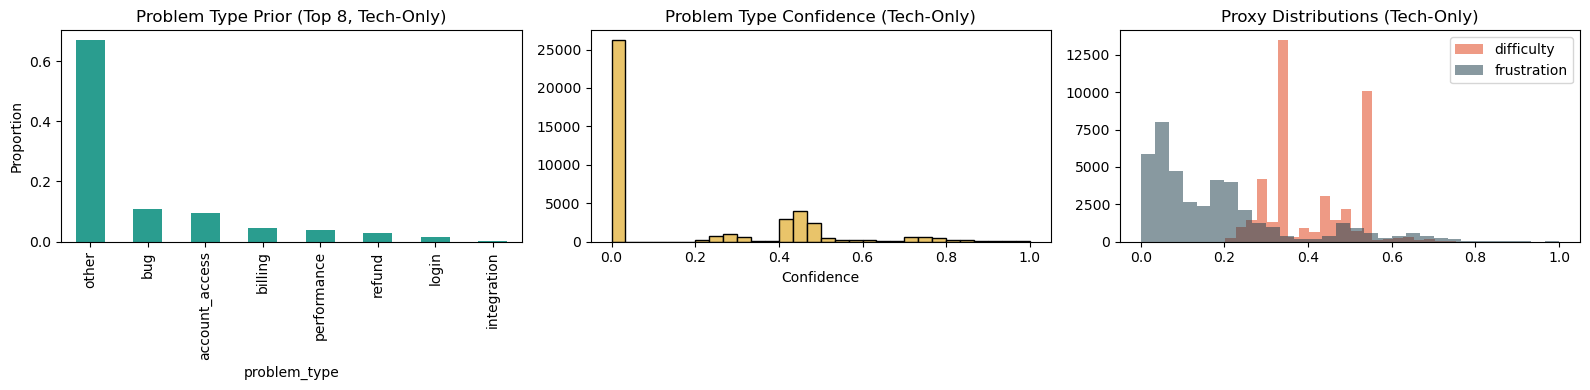

In [ ]:
# Step 3: Visual diagnostics for problem type and proxy distributions (tech-only subset).
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

state_table["problem_type"].value_counts(normalize=True).sort_values(ascending=False).head(8).plot(
    kind="bar", ax=axes[0], title="Problem Type Prior (Top 8, Tech-Only)", color="#2a9d8f"
)
axes[0].set_ylabel("Proportion")

axes[1].hist(state_table["problem_type_confidence"], bins=30, color="#e9c46a", edgecolor="black")
axes[1].set_title("Problem Type Confidence (Tech-Only)")
axes[1].set_xlabel("Confidence")

axes[2].hist(state_table["difficulty_proxy"], bins=30, alpha=0.7, label="difficulty", color="#e76f51")
axes[2].hist(state_table["frustration_proxy"], bins=30, alpha=0.55, label="frustration", color="#264653")
axes[2].set_title("Proxy Distributions (Tech-Only)")
axes[2].legend()

plt.tight_layout()
plt.show()

In [ ]:
# Step 4: Estimate Beta parameters for difficulty by inferred problem type (tech-only subset).
beta_rows = []
for ptype, group in state_table.groupby("problem_type"):
    alpha, beta = _method_of_moments_beta(group["difficulty_proxy"].to_numpy())
    mean_est = alpha / (alpha + beta)
    beta_rows.append({
        "problem_type": ptype,
        "n": int(group.shape[0]),
        "alpha": alpha,
        "beta": beta,
        "beta_mean": mean_est,
    })

beta_df = pd.DataFrame(beta_rows).sort_values("n", ascending=False)
beta_df.head(10)

,problem_type,n,alpha,beta,beta_mean
5,other,28000,10.551026,13.502989,0.438639
2,bug,4539,8.377401,15.539625,0.350269
0,account_access,3909,8.408754,15.841933,0.346743
1,billing,1936,7.301106,12.536296,0.368047
6,performance,1555,8.504453,13.809239,0.381132
7,refund,1242,7.452510,9.017381,0.452493
4,login,599,8.456355,14.263089,0.372208
3,integration,52,7.785470,13.118311,0.372443


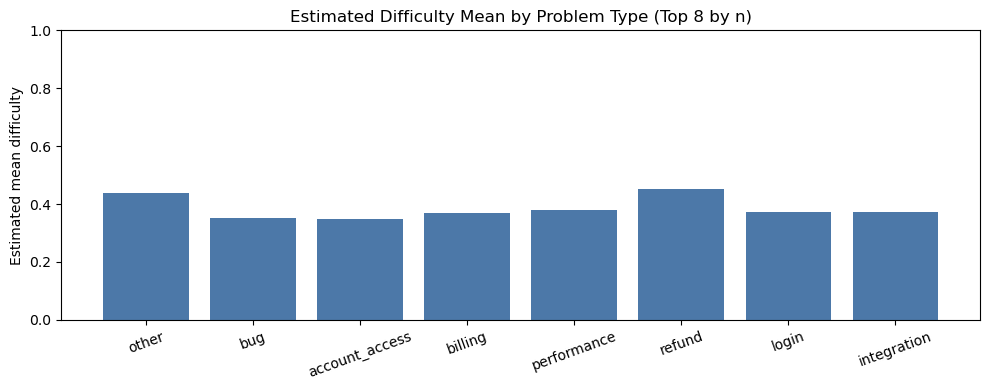

In [ ]:
# Visualize fitted beta means for top problem types by support.
plot_df = beta_df.head(8).copy()

plt.figure(figsize=(10, 4))
plt.bar(plot_df["problem_type"], plot_df["beta_mean"], color="#4c78a8")
plt.title("Estimated Difficulty Mean by Problem Type (Top 8 by n)")
plt.ylabel("Estimated mean difficulty")
plt.ylim(0, 1)
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

Persona profiles:


,rho,sigma,tau
impatient,0.4211,0.6293,0.6131
cooperative,0.8701,0.1764,0.7238
silent_dropoff_prone,0.6943,0.3440,0.6578
escalation_prone,0.7904,0.1939,0.5576


Persona weights:


cooperative             0.4548
impatient               0.3060
escalation_prone        0.1553
silent_dropoff_prone    0.0839
Name: weight, dtype: float64

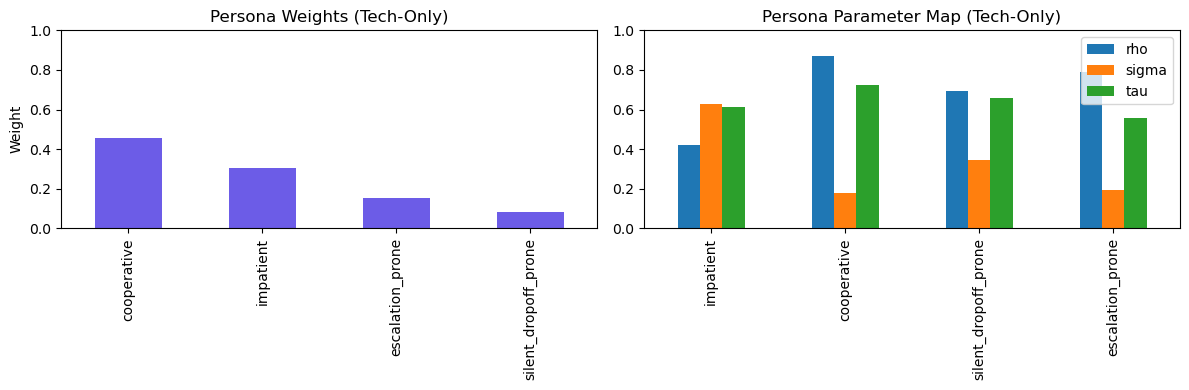

In [ ]:
# Step 5: Persona profile estimation from trajectory proxies (tech-only subset).
persona_profiles, persona_weights = _estimate_personas(state_table, seed=SEED)

persona_profiles_df = pd.DataFrame(persona_profiles).T
persona_weights_s = pd.Series(persona_weights).sort_values(ascending=False)

print("Persona profiles:")
display(persona_profiles_df)
print("Persona weights:")
display(persona_weights_s.rename("weight"))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
persona_weights_s.plot(kind="bar", ax=axes[0], title="Persona Weights (Tech-Only)", color="#6c5ce7")
axes[0].set_ylim(0, 1)
axes[0].set_ylabel("Weight")

persona_profiles_df[["rho", "sigma", "tau"]].plot(kind="bar", ax=axes[1], title="Persona Parameter Map (Tech-Only)")
axes[1].set_ylim(0, 1)
plt.tight_layout()
plt.show()

In [ ]:
# Step 6: Load OpenAssistant and build conversation trees for success-model fitting.
OASST_SAMPLE_FRAC = 1.0

oa_raw = load_openassistant_data(use_parquet=False, sample_frac=OASST_SAMPLE_FRAC, random_state=SEED)
oa_trees = build_conversation_trees(oa_raw)

print("OpenAssistant rows loaded:", len(oa_raw))
print("OpenAssistant trees built:", len(oa_trees))
oa_trees[["num_turns", "avg_rank", "avg_quality", "has_quality_labels"]].head(10)

Loading OpenAssistant from CSV ...
  Loaded 88,838 messages (train=84,437, val=4,401)
Building conversation trees ...
  Built 10,364 conversation trees (0 with quality ratings)
OpenAssistant rows loaded: 88838
OpenAssistant trees built: 10364


,num_turns,avg_rank,avg_quality,has_quality_labels
0,12,1.000000,NaN,False
1,12,0.714286,NaN,False
2,13,1.000000,NaN,False
3,13,0.875000,NaN,False
4,4,1.000000,NaN,False
5,4,0.500000,NaN,False
6,12,0.714286,NaN,False
7,12,0.500000,NaN,False
8,12,0.800000,NaN,False
9,13,1.000000,NaN,False


Fitted success model:
{
  "theta0": 1.693746,
  "theta_i": 0.470529,
  "theta_d": 0.05,
  "theta_f": 0.629104,
  "quality_threshold": 0.915493
}


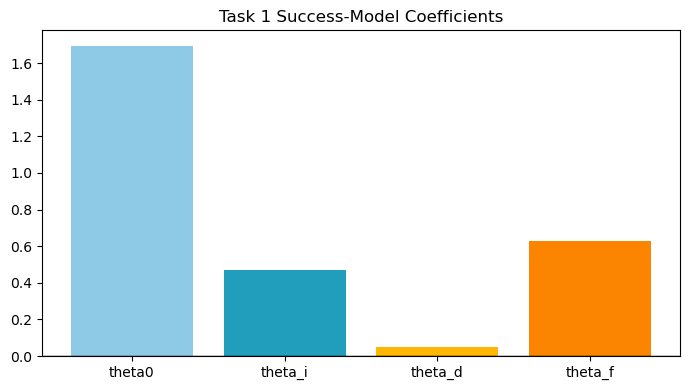

,parameter,value
0,theta0,1.693746
1,theta_i,0.470529
2,theta_d,0.050000
3,theta_f,0.629104


In [ ]:
# Step 7: Fit success-model coefficients and interpret signs.
success_model = _fit_success_model_from_oasst(oa_trees)
print("Fitted success model:")
print(json.dumps(success_model, indent=2))

coef_df = pd.DataFrame({
    "parameter": ["theta0", "theta_i", "theta_d", "theta_f"],
    "value": [success_model["theta0"], success_model["theta_i"], success_model["theta_d"], success_model["theta_f"]],
})

plt.figure(figsize=(7, 4))
plt.bar(coef_df["parameter"], coef_df["value"], color=["#8ecae6", "#219ebc", "#ffb703", "#fb8500"])
plt.axhline(0, color="black", linewidth=1)
plt.title("Task 1 Success-Model Coefficients")
plt.tight_layout()
plt.show()

coef_df

In [ ]:
# Step 8: Build Task 1 artifact using tech-only Twitter estimates plus OASST success model.
problem_type_prior = state_table["problem_type"].value_counts(normalize=True).to_dict()

difficulty_beta_by_problem_type = {
    row["problem_type"]: {
        "alpha": float(row["alpha"]),
        "beta": float(row["beta"]),
        "n": int(row["n"]),
    }
    for _, row in beta_df.iterrows()
}

llm_stats = state_table.attrs.get("problem_type_llm_stats", {})
problem_type_inference_stats = {
    "mean_confidence": float(state_table["problem_type_confidence"].mean()),
    "median_confidence": float(state_table["problem_type_confidence"].median()),
    "non_other_rate": float((state_table["problem_type"] != "other").mean()),
    "weak_non_other_rate": float((state_table["problem_type_weak"] != "other").mean()),
    "llm_refinement": llm_stats,
    "n_threads": int(len(state_table)),
}

artifact = {
    "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
    "data_sources": {
        "twitter_path": str(TWITTER_PATH),
        "twitter_rows_loaded": int(len(tw_raw)),
        "twitter_threads_built": int(len(threads)),
        "twitter_threads_tech_subset": int(len(threads_tech)),
        "openassistant_rows_loaded": int(len(oa_raw)),
        "openassistant_trees_built": int(len(oa_trees)),
    },
    "scope": {
        "twitter_subset": "tech_only",
        "tech_handles_used": tech_present,
        "note": "All Twitter-based calibration parameters are estimated only on the selected tech-company subset.",
    },
    "task1_parameters": {
        "problem_type_prior": problem_type_prior,
        "problem_type_inference_stats": problem_type_inference_stats,
        "difficulty_beta_by_problem_type": difficulty_beta_by_problem_type,
        "persona_profiles": persona_profiles,
        "persona_weights": persona_weights,
        "success_model": success_model,
    },
}

artifact_path = Path(OUTPUT_DIR) / "task1_calibration_notebook_tech_only.json"
artifact_path.parent.mkdir(parents=True, exist_ok=True)
with artifact_path.open("w", encoding="utf-8") as f:
    json.dump(artifact, f, indent=2)

print("Saved notebook artifact:", artifact_path)
print("Top-level keys:", list(artifact.keys()))
print("Data source summary:")
print(json.dumps(artifact["data_sources"], indent=2))
print("LLM refinement summary:")
print(json.dumps(problem_type_inference_stats["llm_refinement"], indent=2))

Saved notebook artifact: /Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/CustomerSupportBandit/outputs/task1_calibration_notebook_tech_only.json
Top-level keys: ['generated_at_utc', 'data_sources', 'scope', 'task1_parameters']
Data source summary:
{
  "twitter_path": "/Users/niyatisingh/Desktop/Sem-6/RL-AML Project/AdaptiveBandit--Contextual-Bandits-for-Real-Time-Decision-Support-in-Customer-Service/datasets/twitter/twcs.csv",
  "twitter_rows_loaded": 1405887,
  "twitter_threads_built": 120000,
  "twitter_threads_tech_subset": 41832,
  "openassistant_rows_loaded": 88838,
  "openassistant_trees_built": 10364
}


In [ ]:
# Step 9: Compare the tech-only notebook artifact with runtime artifact currently used by environment.
runtime_path = Path(OUTPUT_DIR) / "task1_calibration.json"
if runtime_path.exists():
    runtime_artifact = json.loads(runtime_path.read_text(encoding="utf-8"))

    compare = pd.DataFrame([
        {
            "artifact": "runtime",
            "twitter_rows_loaded": runtime_artifact["data_sources"].get("twitter_rows_loaded"),
            "twitter_threads_built": runtime_artifact["data_sources"].get("twitter_threads_built"),
            "openassistant_rows_loaded": runtime_artifact["data_sources"].get("openassistant_rows_loaded"),
            "openassistant_trees_built": runtime_artifact["data_sources"].get("openassistant_trees_built"),
            "theta0": runtime_artifact["task1_parameters"]["success_model"].get("theta0"),
            "theta_i": runtime_artifact["task1_parameters"]["success_model"].get("theta_i"),
            "theta_d": runtime_artifact["task1_parameters"]["success_model"].get("theta_d"),
            "theta_f": runtime_artifact["task1_parameters"]["success_model"].get("theta_f"),
        },
        {
            "artifact": "notebook_tech_only",
            "twitter_rows_loaded": artifact["data_sources"].get("twitter_rows_loaded"),
            "twitter_threads_built": artifact["data_sources"].get("twitter_threads_built"),
            "openassistant_rows_loaded": artifact["data_sources"].get("openassistant_rows_loaded"),
            "openassistant_trees_built": artifact["data_sources"].get("openassistant_trees_built"),
            "theta0": artifact["task1_parameters"]["success_model"].get("theta0"),
            "theta_i": artifact["task1_parameters"]["success_model"].get("theta_i"),
            "theta_d": artifact["task1_parameters"]["success_model"].get("theta_d"),
            "theta_f": artifact["task1_parameters"]["success_model"].get("theta_f"),
        },
    ])
    compare
else:
    print("Runtime artifact not found at", runtime_path)

### Coefficient Interpretation Guide

For the success model

$$
p = \sigma(\theta_0 + \theta_i i - \theta_d d - \theta_f f)
$$

Interpretation:

- $\theta_i$: information benefit. Larger means collecting information strongly improves resolution chance.
- $\theta_d$: difficulty penalty. Larger means difficult cases are harder to resolve automatically.
- $\theta_f$: frustration penalty. Larger means frustration reduces success probability more sharply.
- $\theta_0$: baseline success tendency when other terms are near zero.

Validation checklist when reviewing fitted values:

1. $\theta_i$ should be positive.
2. $\theta_d$ and $\theta_f$ should be positive in the canonical form above.
3. Magnitudes should be plausible and stable across reruns with similar sample settings.
4. Resulting $p$ should not collapse to near 0 or near 1 for most conversations.